# UNSW-NB15 Evaluation


In [109]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [110]:
RANDOM_STATE = 1337

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "padme" / "src" / "main" / "resources" / "data"
OUT_DIR = DATA_DIR / "output"

TRAIN_PATH = DATA_DIR / "input" / "unsw_nb15_train.csv"
TEST_PATH = OUT_DIR / "unsw_nb15_test.csv"

MODES = ["baseline", "padme", "random"]

NODES = 5
BASELINE_NODE = 0

RATIOS = [0.02, 0.04, 0.06, 0.08, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

DROP_COLS = ["__id", "label", "attack_cat", "proto", "service", "state"]
LABEL_COL = "label"


In [111]:
def ratio_to_int(r: float) -> int:
    return int(round(r * 100))

def load_csv_any(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    return pd.read_csv(path)

def load_test(train_csv: Path, test_csv: Path):
    if not test_csv.exists():
        raise FileNotFoundError(f"Required test set not found: {test_csv}. ")

    df_train = load_csv_any(train_csv)
    df_test = load_csv_any(test_csv)

    y_train = df_train[LABEL_COL].astype(int).to_numpy()
    X_train = df_train.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_train.columns])

    y_test = df_test[LABEL_COL].astype(int).to_numpy()
    X_test = df_test.drop(columns=[c for c in [LABEL_COL] + DROP_COLS if c in df_test.columns])

    return X_train, y_train, X_test, y_test

    y = df_train[LABEL_COL].astype(int)
    X = df_train.drop(columns=[c for c in DROP_COLS if c in df_train.columns], errors="ignore")

    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=test_size,random_state=RANDOM_STATE,stratify=y)
    return X_train, y_train.to_numpy(), X_test, y_test.to_numpy()

X_train_full, y_train_full, X_test, y_test = load_test(TRAIN_PATH, TEST_PATH)

feature_cols = list(X_train_full.columns)

print("Train full:", X_train_full.shape, "Test:", X_test.shape, "Pos rate test:", float(np.mean(y_test)))

Train full: (20000, 31) Test: (4000, 31) Pos rate test: 0.2


In [112]:
def node_file(mode: str, ratio_int: int | None, node_idx: int) -> Path:
    if mode == "baseline":
        return OUT_DIR / "baseline" / f"baseline_node{node_idx}.csv"
    return OUT_DIR / mode / str(ratio_int) / f"{mode}_node{node_idx}.csv"

def load_node_dataset(mode: str, ratio: float | None, node_idx: int):
    r_int = None if ratio is None else ratio_to_int(ratio)
    p = node_file(mode, r_int, node_idx)

    df = load_csv_any(p)
    if LABEL_COL not in df.columns:
        raise ValueError(f"{p} does not have column '{LABEL_COL}'.")

    y = df[LABEL_COL].astype(int).to_numpy()
    X = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")
    X = X.reindex(columns=feature_cols, fill_value=0.0)

    return X, y, str(p)

def pr_auc(model, Xtr, ytr, Xte, yte) -> float:
    model.fit(Xtr, ytr)
    if hasattr(model, "predict_proba"):
        p = model.predict_proba(Xte)[:, 1]
    else:
        s = model.decision_function(Xte)
        p = 1 / (1 + np.exp(-s))
    return float(average_precision_score(yte, p))

In [113]:
stats_rows = []

for mode in ["baseline", "random", "padme"]:
    if mode == "baseline":
        ratios_to_check = [None]
    else:
        ratios_to_check = RATIOS

    for r in ratios_to_check:
        for i in range(NODES):
            Xn, yn, pn = load_node_dataset(mode, r, i)

            yn_series = pd.Series(yn)
            pos = int((yn_series == 1).sum())
            neg = int((yn_series == 0).sum())
            total = int(len(yn_series))

            stats_rows.append({
                "mode": mode,
                "keep_ratio": 1.0 if r is None else float(r),
                "ratio_int": 100 if r is None else ratio_to_int(r),
                "node": i,
                "rows": total,
                "positives": pos,
                "negatives": neg,
                "positive_ratio": (pos / total) if total > 0 else np.nan,
                "file": str(pn)
            })

stats_df = pd.DataFrame(stats_rows).sort_values(
    ["mode", "keep_ratio", "node"]
).reset_index(drop=True)

stats_df

,mode,keep_ratio,ratio_int,node,rows,positives,negatives,positive_ratio,file
0,baseline,1.0,100,0,20000,4000,16000,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
1,baseline,1.0,100,1,20000,4000,16000,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
2,baseline,1.0,100,2,20000,4000,16000,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
3,baseline,1.0,100,3,20000,4000,16000,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
4,baseline,1.0,100,4,20000,4000,16000,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
...,...,...,...,...,...,...,...,...,...
130,random,0.9,90,0,3600,720,2880,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
131,random,0.9,90,1,3600,721,2879,0.200278,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
132,random,0.9,90,2,3600,695,2905,0.193056,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...
133,random,0.9,90,3,3600,720,2880,0.200000,C:\Users\Legion\Desktop\FEUP\Dissertação\PADME...


In [114]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",
            max_iter=5000,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ]),
    "SGD": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(
            loss="log_loss",
            max_iter=5000,
            tol=1e-3,
            random_state=RANDOM_STATE
        ))
    ]),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

In [115]:
def eval_auc_metrics(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    pr_auc = average_precision_score(y_test, p)
    roc_auc = roc_auc_score(y_test, p)
    return pr_auc, roc_auc

rows = []

for model_name, model in models.items():
    Xb, yb, pb = load_node_dataset("baseline", None, BASELINE_NODE)
    base_pr_auc, base_roc_auc = eval_auc_metrics(model, Xb, yb, X_test, y_test)

    rows.append({
        "model": model_name,
        "mode": "baseline",
        "keep_ratio": 1.0,
        "ratio_int": 100,
        "node": BASELINE_NODE,
        "pr_auc": base_pr_auc,
        "roc_auc": base_roc_auc,
        "pr_auc_mean": base_pr_auc,
        "pr_auc_std": 0.0,
        "roc_auc_mean": base_roc_auc,
        "roc_auc_std": 0.0
    })

    for mode in ["random", "padme"]:
        for r in RATIOS:
            pr_scores = []
            roc_scores = []

            for i in range(NODES):
                Xn, yn, pn = load_node_dataset(mode, r, i)
                pr_s, roc_s = eval_auc_metrics(model, Xn, yn, X_test, y_test)

                pr_scores.append(pr_s)
                roc_scores.append(roc_s)

                rows.append({
                    "model": model_name,
                    "mode": mode,
                    "keep_ratio": r,
                    "ratio_int": ratio_to_int(r),
                    "node": i,
                    "pr_auc": pr_s,
                    "roc_auc": roc_s,
                    "file": pn
                })

            rows.append({
                "model": model_name,
                "mode": mode,
                "keep_ratio": r,
                "ratio_int": ratio_to_int(r),
                "node": "mean",
                "pr_auc": float(np.mean(pr_scores)),
                "roc_auc": float(np.mean(roc_scores)),
                "pr_auc_mean": float(np.mean(pr_scores)),
                "pr_auc_std": float(np.std(pr_scores, ddof=1)) if len(pr_scores) > 1 else 0.0,
                "roc_auc_mean": float(np.mean(roc_scores)),
                "roc_auc_std": float(np.std(roc_scores, ddof=1)) if len(roc_scores) > 1 else 0.0
            })

results = pd.DataFrame(rows)

results[(results["node"] == "mean") | (results["mode"] == "baseline")].sort_values(
    ["model", "mode", "keep_ratio"]
)

,model,mode,keep_ratio,ratio_int,node,pr_auc,roc_auc,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,file
314,ExtraTrees,baseline,1.00,100,0,0.924340,0.975290,0.924340,0.000000,0.975290,0.000000,NaN
398,ExtraTrees,padme,0.02,2,mean,0.759639,0.928233,0.759639,0.010844,0.928233,0.021229,NaN
404,ExtraTrees,padme,0.04,4,mean,0.763452,0.932538,0.763452,0.035646,0.932538,0.011654,NaN
410,ExtraTrees,padme,0.06,6,mean,0.819754,0.947528,0.819754,0.032088,0.947528,0.009840,NaN
416,ExtraTrees,padme,0.08,8,mean,0.811679,0.949269,0.811679,0.034431,0.949269,0.010967,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
211,SGD,random,0.50,50,mean,0.638444,0.856862,0.638444,0.031176,0.856862,0.016153,NaN
217,SGD,random,0.60,60,mean,0.584576,0.877256,0.584576,0.056022,0.877256,0.017787,NaN
223,SGD,random,0.70,70,mean,0.653671,0.875295,0.653671,0.019899,0.875295,0.016562,NaN
229,SGD,random,0.80,80,mean,0.642711,0.886635,0.642711,0.049417,0.886635,0.009300,NaN


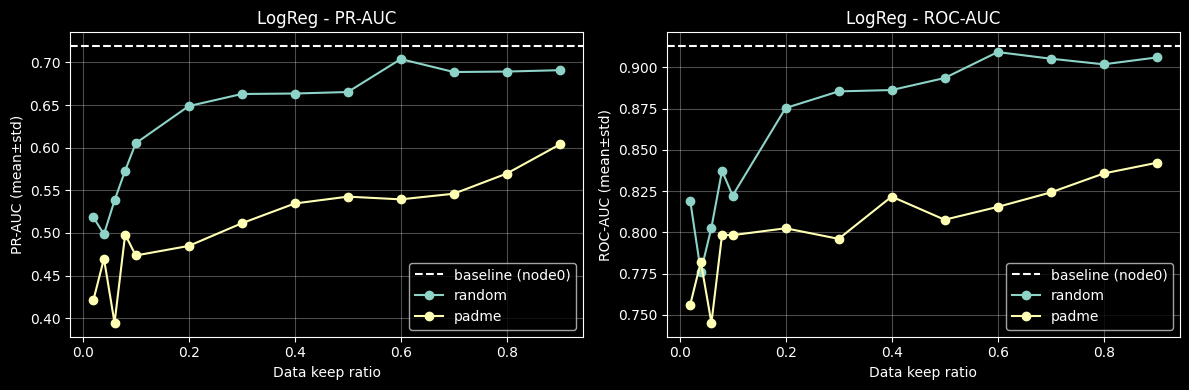

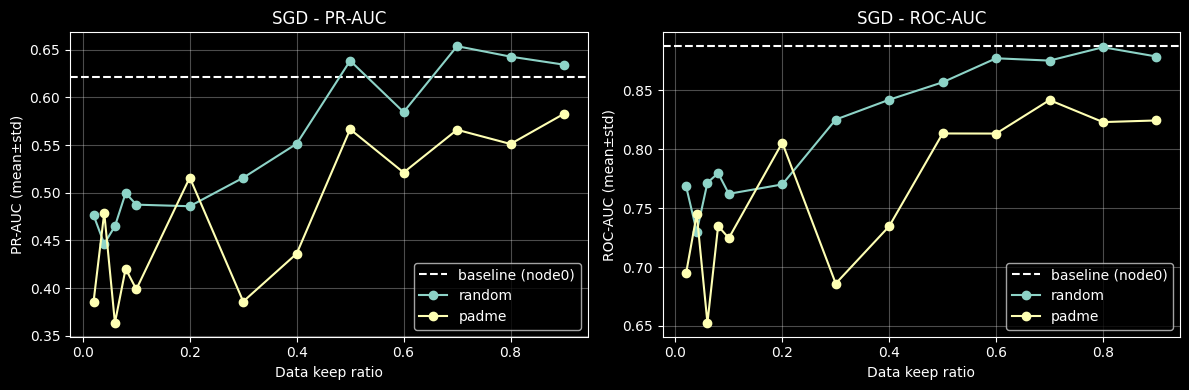

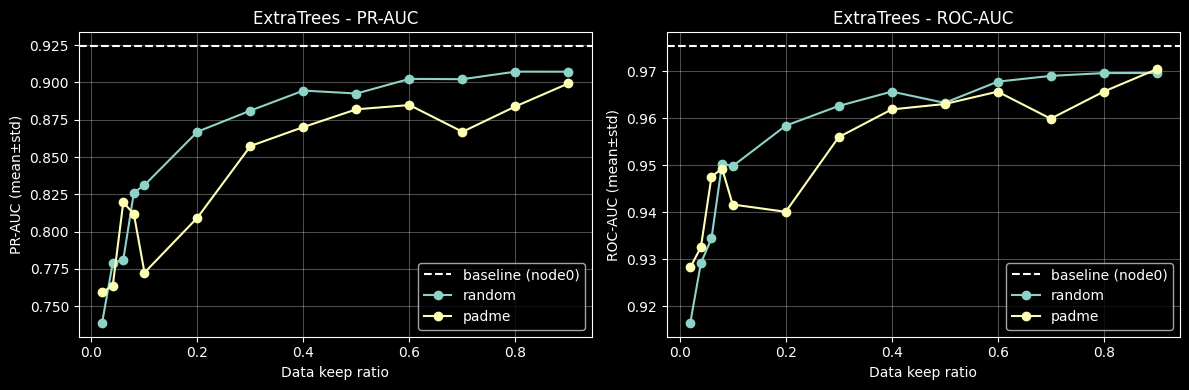

In [116]:
for model_name in models.keys():
    sub_mean = results[(results["model"] == model_name) & (results["node"] == "mean")].copy()
    base_row = results[(results["model"] == model_name) & (results["mode"] == "baseline")].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    metrics = [
        ("pr_auc", "PR-AUC"),
        ("roc_auc", "ROC-AUC"),
    ]

    for ax, (metric_key, metric_label) in zip(axes, metrics):
        base = base_row[f"{metric_key}_mean"]
        ax.axhline(base, linestyle="--", label=f"baseline (node{BASELINE_NODE})")

        for mode in ["random", "padme"]:
            s = sub_mean[sub_mean["mode"] == mode].sort_values("keep_ratio")
            ax.errorbar(
                s["keep_ratio"],
                s[f"{metric_key}_mean"],
                marker="o",
                capsize=3,
                label=mode
            )

        ax.set_xlabel("Data keep ratio")
        ax.set_ylabel(f"{metric_label} (mean±std)")
        ax.set_title(f"{model_name} - {metric_label}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()